In [1]:
import pandas as pd
import pygridmet as gridmet

In [2]:
# Read main dataset

df = pd.read_csv("calfire_topography_vegetation_joined.csv")
df.head()

,incident_name,incident_is_final,incident_date_last_update,incident_date_created,incident_administrative_unit,incident_administrative_unit_url,incident_county,incident_location,incident_acres_burned,incident_containment,...,FUEL_VARIATION,PERCENT,NAME,GACC,GROUP,veg_LAT,veg_LON,ELE,veg_date,date_gap_days
0,Bridge Fire,Y,2018-01-09T13:46:00Z,2017-10-31T11:22:00Z,Shasta-Trinity National Forest,NaN,Shasta,"I-5 and Turntable Bay, 7 miles NE of Shasta Lake",37.0,100.0,...,Whiteleaf,73.0,Lakeshore,NOCC,Shasta-Trinity NF,40.870833,-122.389722,1085.0,2017-10-18,13
1,Lake Fire,Y,2013-05-18T19:00:00Z,2013-05-17T13:23:00Z,CAL FIRE/Los Angeles County,NaN,Los Angeles,I-5 Southbound at Lake Hughes Road,712.0,100.0,...,NaN,61.0,"Bitter Canyon, Castaic",SOCC,LA County,34.510000,-118.594500,1745.0,2013-05-17,0
2,Shelton Fire,Y,2013-05-30T13:25:00Z,2013-05-30T11:20:00Z,CAL FIRE Tuolumne-Calaveras Unit,NaN,San Joaquin,off North Shelton Rd in the Linden Peters area,303.0,100.0,...,New Growth,82.0,Valley Springs,SOCC,CAL FIRE Toulumne-Calaveras Unit,38.114722,-120.790000,908.0,2013-05-23,7
3,Border Fire,Y,2013-05-23T08:30:00Z,2013-05-22T16:14:00Z,CAL FIRE San Diego Unit,NaN,San Diego,Off Alta Rd in the Otay Mesa area,100.0,100.0,...,New Growth,88.0,Barrett,SOCC,SDG&E,32.666389,-116.700000,2500.0,2013-05-20,2
4,San Felipe Fire,Y,2022-10-24T11:41:15Z,2013-05-23T12:20:00Z,CAL FIRE San Diego Unit,NaN,San Diego,"San Felipe Road, north of Highway 78, East of ...",2650.0,100.0,...,New Growth,90.0,San Felipe,SOCC,SDG&E,33.197500,-116.598056,3452.0,2013-05-23,0


In [3]:
df.iloc[1].index

Index(['incident_name', 'incident_is_final', 'incident_date_last_update',
       'incident_date_created', 'incident_administrative_unit',
       'incident_administrative_unit_url', 'incident_county',
       'incident_location', 'incident_acres_burned', 'incident_containment',
       'incident_control', 'incident_cooperating_agencies', 'fire_LON',
       'fire_LAT', 'incident_type', 'incident_id', 'incident_url',
       'incident_date_extinguished', 'incident_dateonly_extinguished',
       'incident_dateonly_created', 'is_active', 'calfire_incident',
       'notification_desired', 'created', 'log_acres', 'aspect', 'elevation',
       'first', 'hillshade', 'slope', 'fire_date', 'fire_id',
       'matched_veg_LAT', 'matched_veg_LON', 'location_distance_degrees',
       'STID', 'DATE', 'FUEL_TYPE', 'FUEL_VARIATION', 'PERCENT', 'NAME',
       'GACC', 'GROUP', 'veg_LAT', 'veg_LON', 'ELE', 'veg_date',
       'date_gap_days'],
      dtype='str')

In [4]:

variables = [
    "pr", "rmax", "rmin", "sph", "srad", "th",
    "tmmn", "tmmx", "vs", "bi", "fm100", "fm1000",
    "erc", "etr", "pet", "vpd"
]

results = []
failed = []

for i in range(len(df)):

    fire = df.iloc[i]

    coords = (fire["fire_LON"], fire["fire_LAT"])

    dates = (
        fire["incident_dateonly_created"],
        fire["incident_dateonly_created"]
    )

    try:

        df_gridmet = gridmet.get_bycoords(
            coords=coords,
            dates=dates,
            variables=variables
        )

        df_gridmet["lon"] = fire["fire_LON"]
        df_gridmet["lat"] = fire["fire_LAT"]
        df_gridmet["fire_start_date"] = fire["incident_dateonly_created"]
        df_gridmet['original_index'] = i

        results.append(df_gridmet)

        if i % 100 == 0:
            print(f"Processed {i}/{len(df)}")

    except Exception as e:

        print(f"Failed row {i}")
        print(f"coords={coords}")
        print(f"date={fire['incident_dateonly_created']}")
        print(f"error={e}")

        failed.append({
            "row": i,
            "fire_LON": fire["fire_LON"],
            "fire_LAT": fire["fire_LAT"],
            "fire_start_date": fire["incident_dateonly_created"],
            "error": str(e)
        })

# Combine successful downloads
gridmet_all = pd.concat(results, ignore_index=True)

# Log failures
failed_df = pd.DataFrame(failed)

print(f"Successful: {len(results)}")
print(f"Failed: {len(failed_df)}")

Processed 0/2576
Processed 100/2576
Processed 200/2576
Failed row 262
coords=(np.float64(-124.19629), np.float64(41.93323))
date=2017-06-26
error=Service returned the following error message:
GridMET did NOT process your request successfully. Check your inputs and try again.
Processed 300/2576
Processed 400/2576
Processed 500/2576
Processed 600/2576
Processed 700/2576
Processed 800/2576
Failed row 877
coords=(np.float64(-124.19954), np.float64(40.78804))
date=2020-07-27
error=Service returned the following error message:
GridMET did NOT process your request successfully. Check your inputs and try again.
Processed 900/2576
Processed 1000/2576
Processed 1100/2576
Failed row 1117
coords=(np.float64(-120.2770391), np.float64(34.4687419))
date=2022-03-12
error=Service returned the following error message:
GridMET did NOT process your request successfully. Check your inputs and try again.
Failed row 1124
coords=(np.float64(-117.744398), np.float64(33.509464))
date=2022-05-11
error=Service re

In [5]:
gridmet_all.columns

Index(['pr (mm)', 'rmax (%)', 'rmin (%)', 'sph (kg/kg)', 'srad (W/m2)',
       'th (Degrees clockwise from north)', 'tmmn (K)', 'tmmx (K)', 'vs (m/s)',
       'bi (-)', 'fm100 (%)', 'fm1000 (%)', 'erc (-)', 'etr (mm)', 'pet (mm)',
       'vpd (kPa)', 'lon', 'lat', 'fire_start_date', 'original_index'],
      dtype='str')

In [6]:
# Join this back to the main df
df = df.merge(gridmet_all,how='left',left_index=True, right_index = False, right_on = 'original_index')
pd.DataFrame.to_csv(df,'calfire_topography_vegetation_weather_joined.csv')

In [10]:
df.columns

Index(['incident_name', 'incident_is_final', 'incident_date_last_update',
       'incident_date_created', 'incident_administrative_unit',
       'incident_administrative_unit_url', 'incident_county',
       'incident_location', 'incident_acres_burned', 'incident_containment',
       'incident_control', 'incident_cooperating_agencies', 'fire_LON',
       'fire_LAT', 'incident_type', 'incident_id', 'incident_url',
       'incident_date_extinguished', 'incident_dateonly_extinguished',
       'incident_dateonly_created', 'is_active', 'calfire_incident',
       'notification_desired', 'created', 'log_acres', 'aspect', 'elevation',
       'first', 'hillshade', 'slope', 'fire_date', 'fire_id',
       'matched_veg_LAT', 'matched_veg_LON', 'location_distance_degrees',
       'STID', 'DATE', 'FUEL_TYPE', 'FUEL_VARIATION', 'PERCENT', 'NAME',
       'GACC', 'GROUP', 'veg_LAT', 'veg_LON', 'ELE', 'veg_date',
       'date_gap_days', 'pr (mm)', 'rmax (%)', 'rmin (%)', 'sph (kg/kg)',
       'srad (W/m2

In [ ]:
# Data visualization on the gridmet

cols_of_interest = ['pr (mm)', 'rmax (%)', 'rmin (%)', 'sph (kg/kg)', 'srad (W/m2)', 
'th (Degrees clockwise from north)', 'tmmn (K)', 'tmmx (K)', 'vs (m/s)', 'bi (-)', 
'fm100 (%)', 'fm1000 (%)', 'erc (-)', 'etr (mm)', 'pet (mm)', 'vpd (kPa)', 'incident_acres_burned']
print(df[cols_of_interest].dtypes)


pr (mm)                              float32
rmax (%)                             float32
rmin (%)                             float32
sph (kg/kg)                          float32
srad (W/m2)                          float32
th (Degrees clockwise from north)    float32
tmmn (K)                             float32
tmmx (K)                             float32
vs (m/s)                             float32
bi (-)                               float32
fm100 (%)                            float32
fm1000 (%)                           float32
erc (-)                              float32
etr (mm)                             float32
pet (mm)                             float32
vpd (kPa)                            float32
incident_acres_burned                float64
dtype: object


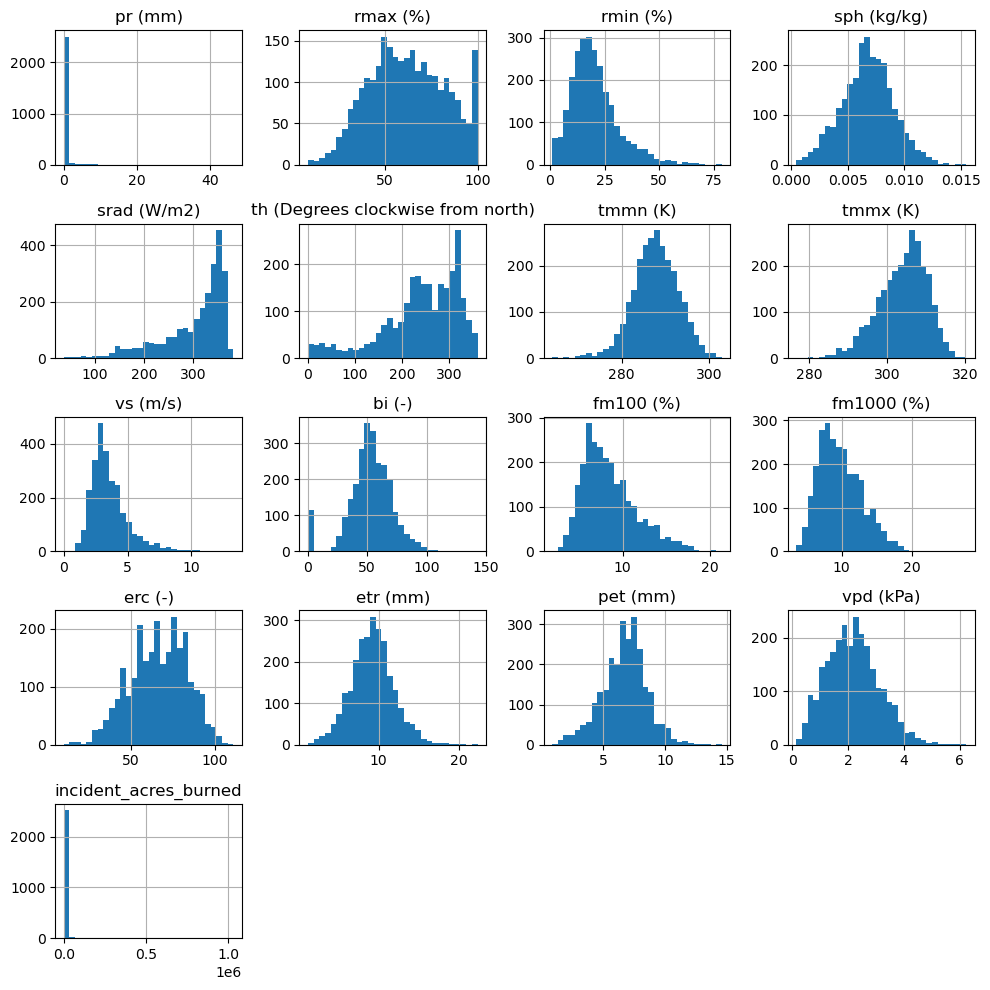

In [ ]:
df[cols_of_interest].hist(
    figsize=(10, 10),
    bins=30,
    layout=(5, 4)
)

plt.tight_layout()
plt.show()

print("Try log transforming pr (mm) and incident_acres_burned")

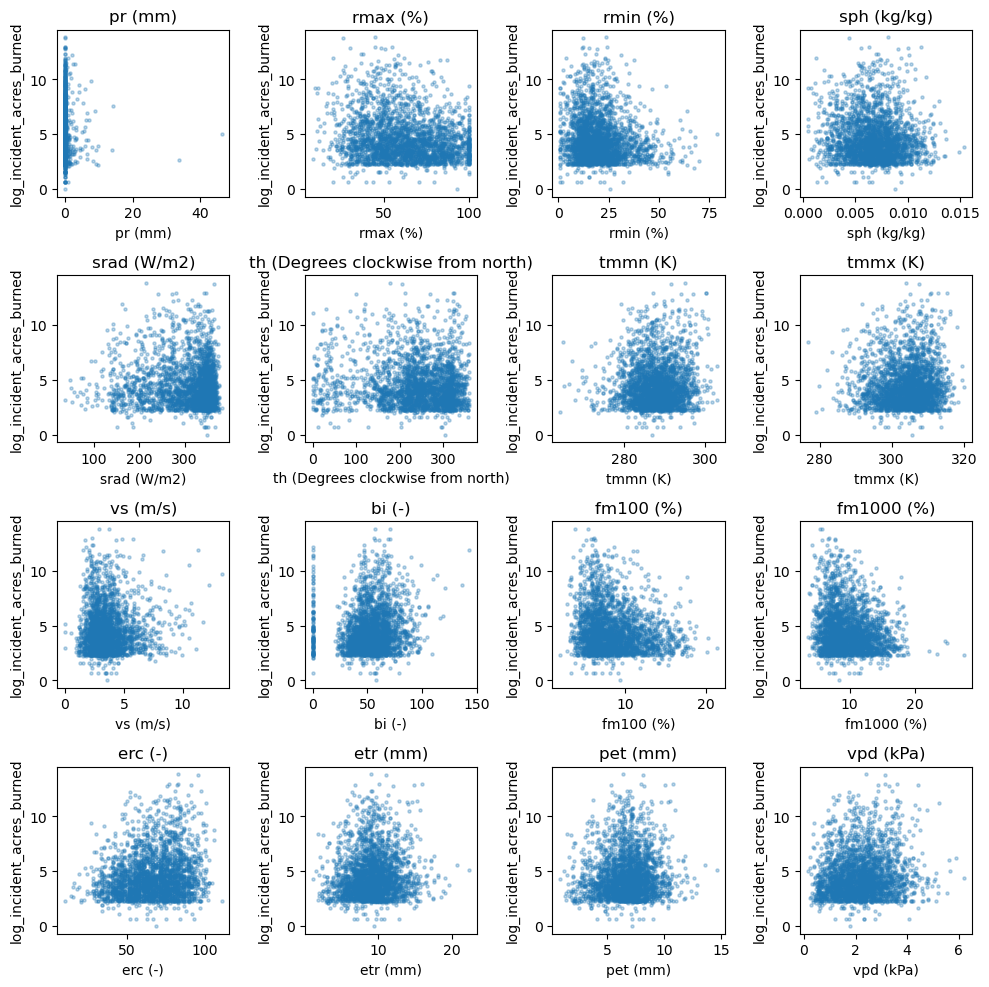

In [42]:
import numpy as np

input_columns = [
    'pr (mm)', 'rmax (%)', 'rmin (%)', 'sph (kg/kg)', 'srad (W/m2)',
    'th (Degrees clockwise from north)', 'tmmn (K)', 'tmmx (K)',
    'vs (m/s)', 'bi (-)', 'fm100 (%)', 'fm1000 (%)',
    'erc (-)', 'etr (mm)', 'pet (mm)', 'vpd (kPa)'
]

fig, axes = plt.subplots(5, 4, figsize=(10,12))
axes = axes.flatten()

for i, col in enumerate(input_columns):
    axes[i].scatter(
        df[col],
        np.log(df['incident_acres_burned']),
        alpha=0.3,
        s=5
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_incident_acres_burned')

# Remove unused plots (20 spots, 16 variables)
for ax in axes[len(input_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()